embeddings contextuais com bertimbau em tweets #edtwt

In [2]:
%pip install transformers scikit-learn plotly seaborn matplotlib pandas numpy nbformat>=4.2.0 --quiet

zsh:1: 4.2.0 not found
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
import ast
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

seed = 42

carregamento dos dados

In [4]:
DATA_DIR = os.getcwd()
csv_path = os.path.join(DATA_DIR, '..', 'entregas', 'p4', 'entrega_4.csv')
json_path = os.path.join(DATA_DIR, '..', 'entregas', 'p4', 'entrega_4_bert_features.json')

for p in [csv_path, json_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'Arquivo não encontrado: {p}')

df = pd.read_csv(csv_path)
print(f'Dataset: {df.shape[0]} tweets, {df.shape[1]} colunas')
print(f'Colunas: {list(df.columns)}')

Dataset: 2815 tweets, 37 colunas
Colunas: ['search_date', 'id', 'url', 'text', 'source', 'created_at', 'lang', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'view_count', 'bookmark_count', 'conversation_id', 'in_reply_to_id', 'in_reply_to_user_id', 'in_reply_to_username', 'is_reply', 'is_limited_reply', 'author_id', 'author_name', 'author_username', 'author_url', 'author_followers', 'author_following', 'hashtags', 'urls', 'mentions', 'tokenizacao_nltk', 'remocao_stopwords_spacy', 'stemming_nltk', 'normalizacao_re', 'features_tfidf_sklearn', 'tokens_word2vec', 'vetor_medio_word2vec', 'emb_bertimbau_input', 'emb_bertimbau_mean']


In [5]:
with open(json_path, 'r') as f:
    bert_config = json.load(f)

print('configuração do modelo bertimbau:')
for k, v in bert_config.items():
    print(f'  {k}: {v}')

configuração do modelo bertimbau:
  modelo: neuralmind/bert-base-portuguese-cased
  vector_size: 768
  pooling: mean
  batch_size: 16
  max_length: 128
  device: cpu


In [6]:
def parse_vetor(vetor_str):
    if pd.isna(vetor_str):
        return None
    try:
        return np.array(ast.literal_eval(vetor_str), dtype=np.float32)
    except (ValueError, SyntaxError):
        return None

df['vetor_parsed'] = df['emb_bertimbau_mean'].apply(parse_vetor)

valid_mask = df['vetor_parsed'].notna()
vetores = np.stack(df.loc[valid_mask, 'vetor_parsed'].values)
documentos = df.loc[valid_mask, 'text'].values
inputs_bert = df.loc[valid_mask, 'emb_bertimbau_input'].values

print(f'Vetores carregados: {vetores.shape}')
print(f'Dimensão de cada vetor: {vetores.shape[1]}')
print(f'Total de documentos válidos: {len(documentos)}')

Vetores carregados: (2815, 768)
Dimensão de cada vetor: 768
Total de documentos válidos: 2815


diagnóstico da similaridade de cosseno

In [7]:
sim_raw = cosine_similarity(vetores)
upper_raw = sim_raw[np.triu_indices_from(sim_raw, k=1)]

print('=== Similaridade de Cosseno ORIGINAL (sem centralização) ===')
print(f'  Média: {upper_raw.mean():.6f}')
print(f'  Desvio padrão: {upper_raw.std():.6f}')
print(f'  Mínimo: {upper_raw.min():.4f}  |  Máximo: {upper_raw.max():.4f}')
print(f'  Mediana: {np.median(upper_raw):.6f}')

=== Similaridade de Cosseno ORIGINAL (sem centralização) ===
  Média: 0.768169
  Desvio padrão: 0.069603
  Mínimo: 0.2270  |  Máximo: 1.0000
  Mediana: 0.773699


In [8]:
vetor_medio_global = vetores.mean(axis=0)
vetores_centralizados = vetores - vetor_medio_global

sim_cent = cosine_similarity(vetores_centralizados)
upper_cent = sim_cent[np.triu_indices_from(sim_cent, k=1)]

print('=== Similaridade de Cosseno CENTRALIZADA (mean-centering) ===')
print(f'  Média: {upper_cent.mean():.6f}')
print(f'  Desvio padrão: {upper_cent.std():.6f}')
print(f'  Mínimo: {upper_cent.min():.4f}  |  Máximo: {upper_cent.max():.4f}')
print(f'  Mediana: {np.median(upper_cent):.6f}')

=== Similaridade de Cosseno CENTRALIZADA (mean-centering) ===
  Média: 0.000354
  Desvio padrão: 0.193302
  Mínimo: -0.6024  |  Máximo: 1.0000
  Mediana: -0.014190


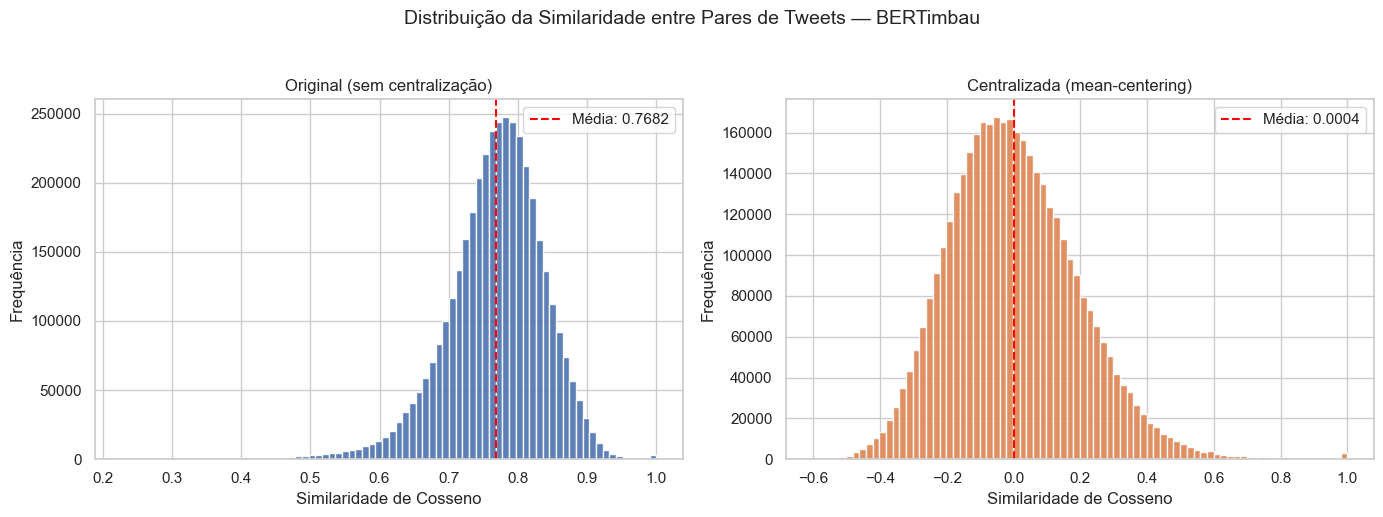

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(upper_raw, bins=80, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0].axvline(upper_raw.mean(), color='red', linestyle='--', label=f'Média: {upper_raw.mean():.4f}')
axes[0].set_title('Original (sem centralização)', fontsize=12)
axes[0].set_xlabel('Similaridade de Cosseno')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].hist(upper_cent, bins=80, color='#DD8452', edgecolor='white', alpha=0.9)
axes[1].axvline(upper_cent.mean(), color='red', linestyle='--', label=f'Média: {upper_cent.mean():.4f}')
axes[1].set_title('Centralizada (mean-centering)', fontsize=12)
axes[1].set_xlabel('Similaridade de Cosseno')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('Distribuição da Similaridade entre Pares de Tweets — BERTimbau', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

heatmap de similaridade centralizada (amostra)

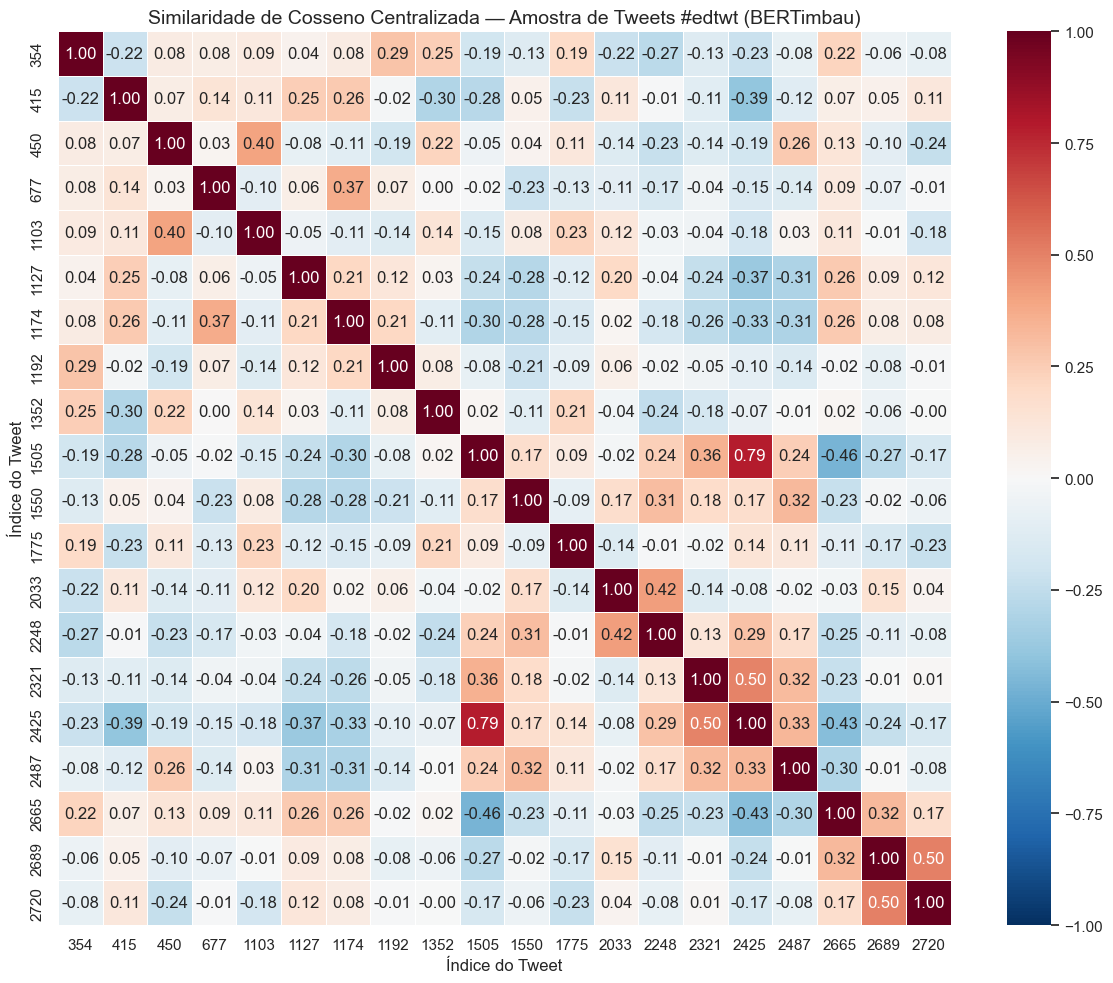

In [10]:
np.random.seed(seed)
n_amostra = min(20, len(documentos))
indices_amostra = np.sort(np.random.choice(len(documentos), size=n_amostra, replace=False))

matriz_amostra = sim_cent[np.ix_(indices_amostra, indices_amostra)]
labels = [str(i) for i in indices_amostra]

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_amostra,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=.5,
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1, vmax=1
)
plt.title('Similaridade de Cosseno Centralizada — Amostra de Tweets #edtwt (BERTimbau)', fontsize=14)
plt.xlabel('Índice do Tweet', fontsize=12)
plt.ylabel('Índice do Tweet', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
print('tweets da amostra:')
for i in indices_amostra:
    texto = documentos[i].replace('\n', ' ')[:90]
    print(f'  [{i}] {texto}{"..." if len(documentos[i]) > 90 else ""}')

tweets da amostra:
  [354] Fui me pesar e tô com 77 kg #fatspo #feederism #edtwt https://t.co/haFNW9k57M
  [415] uma pequena dica não óbvia para muitos, se você ainda come demais, quando vc ta comendo, v...
  [450] Busco mutis otra vez  arriba los edgys #shedtwt #edtwt #obstwt de todo menos pedotwt o zot...
  [677] dando uma de #edtwt pq eu to com mt fome pra jantar mas já passei as calorias do dia hoje ...
  [1103] quando eu pensar em comer vou pensar nela, tão bebezinha, pequena e delicada, a winter é m...
  [1127] Eu so vou conseguir mudar m8nha vida de verdade quando eu for magra, porquê existem duas v...
  [1174] amigos do #edtwt indicação de site pra vocês (se vcs não conhecerem) tem vaaaarias receita...
  [1192] é galera, eu oficialmente entrei na casa dos 70 quilos, eu tô muito feliz 😭😭😭🫶🫶🫶🎉🎉 #edtwt ...
  [1352] Café da manhã💗 ~94 kcal &gt;&lt; #edtwt https://t.co/sONafkX4Yh
  [1505] @ryanmaluco vai ter #edtwt hoje
  [1550] vomitei meu almoço, posso fazer parte do #edtwt e ser 

busca semântica por similaridade

In [12]:
import torch
from transformers import AutoTokenizer, AutoModel

bert_model_name = bert_config.get('modelo', 'neuralmind/bert-base-portuguese-cased')
tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
modelo_bert = AutoModel.from_pretrained(bert_model_name)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
modelo_bert.to(device)
modelo_bert.eval()

@torch.no_grad()
def embed_query(texto, tokenizer, model, device):
    inputs = tokenizer(
        [texto],
        padding=True,
        truncation=True,
        max_length=bert_config.get('max_length', 128),
        return_tensors='pt'
    ).to(device)
    outputs = model(**inputs)
    mask = inputs['attention_mask'].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
    summed = torch.sum(outputs.last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    vetor = (summed / counts).cpu().numpy()[0]
    return vetor

def buscar_tweets_bert(consulta, documentos, vetores_cent, vetor_medio_global, num_resultados=10):
    vetor_busca_bruto = embed_query(consulta, tokenizer, modelo_bert, device)
    vetor_busca_cent = vetor_busca_bruto - vetor_medio_global
    similaridades = cosine_similarity(vetor_busca_cent.reshape(1, -1), vetores_cent)[0]
    indices_ranqueados = np.argsort(similaridades)[::-1]
    pd.set_option('display.max_colwidth', None)
    resultados = pd.DataFrame({
        'Tweet': [documentos[i].replace('\n', ' ')[:1000] for i in indices_ranqueados[:num_resultados]],
        'Similaridade': similaridades[indices_ranqueados[:num_resultados]]
    })
    return resultados

termo = input('Digite os termos de busca: ')
resultados = buscar_tweets_bert(termo, documentos, vetores_centralizados, vetor_medio_global)
if not resultados.empty:
    print(f'\nTop {len(resultados)} resultados para "{termo}":')
resultados


Top 10 resultados para "emagrecer":


,Tweet,Similaridade
0,"eu: ""to em recovery, mas não vou engordar e sim emagrecer"" eu também comendo 80 calorias hoje e com gastura de ver comida na minha frente",0.580231
1,emagreci 2kg em 2 semanas #edtwt,0.578954
2,emagreci 5kg em menos de dois meses tomando venlafaxina pqp depressao is over #edtwt,0.559838
3,entrando p #edtwt depois de ter emagrecido 5kg,0.525690
4,"Ultima refeição “livre”, de agora em diante eu vou conseguir emagrecer #edtwt",0.523516
5,gente como é que faz mesmo pra calcular até quantas kcal eu posso ingerir pra continuar emagrecendo? #edtwt,0.516916
6,"Ter conhecido o #edtwt foi uma das melhores coisas que me ocorreu, n ligo de ser uma possível transtornada, mas pelo menos eu emagreci e estou emagrecendo. Ainda não cheguei na minha meta, mas com um pouco mais de esforço eu chego lá 😌",0.510274
7,︶ ⏝ ︶ ୨୧ ︶ ⏝ ︶ | JANTA. | Peso atual :: 52kg . | Meta :: 45kg . | Tgs :: #EdTwt #Emagrecimento (estava desde das 4hrs sem comer) https://t.co/vtFuP42sbo,0.506983
8,oi vou desistir do recovery 😇💗💗💗💗 QUERO MEUS 35KG DE VOLTA . EU TO GORDAAAAAA,0.503915
9,quero emagrecer uns 6kg até final do ano #edtwt 😍🥰,0.497835


agrupamento (clustering) com kmeans

In [13]:
num_clusters = 3

kmeans = KMeans(n_clusters=num_clusters, random_state=seed, n_init=10)
kmeans.fit(vetores_centralizados)

df_cluster = pd.DataFrame({'Tweet': documentos, 'Cluster': kmeans.labels_})

print(f'Agrupamento com {num_clusters} clusters:\n')
for c in range(num_clusters):
    cluster = df_cluster[df_cluster['Cluster'] == c]
    print(f'  Cluster {c} ({len(cluster)} tweets):')
    for s in cluster['Tweet'].head(3):
        print(f'    - {s.replace(chr(10), " ")[:100]}')
    print()

Agrupamento com 3 clusters:

  Cluster 0 (984 tweets):
    - em quanto tempo vocês tiveram resultados notáveis na academia ?  #edtwt #gymtwt #gymgirl
    - A geladeira do edtwt que mora sozinha  #edtwt #nofood  #diet #zerosugar https://t.co/SRvInSbGuj
    - tomando um milkymoo cacau de 700ml ~♡~ #edtwt https://t.co/CqlGrQH3ZC

  Cluster 1 (841 tweets):
    - dica pro #edtwt se inscrever pro bbb
    - necesito mutis de #edtwt 😞
    - Alguém aqui conversa comigo, plmds #edtwt

  Cluster 2 (990 tweets):
    - Refeições de hj! #wieiad ₍ᐢ. .ᐢ₎ ．☆．。．:*･ﾟ  Gente eu esqueci de tirar foto do almoço, mas foi arroz 
    - Talvez, só talvez eu tenha dismofia corporal.  Uma amiga que eu jurava q tínhamos o mesmo corpo veio
    - cade a comunidade #edtwt ? quwro amizades, vamos nos motivas bbzudos !



alimentação, exercício, relacionamentos e autoimagem

visualização 2d com pca e t-sne

In [14]:
pca_2d = PCA(n_components=2, random_state=seed)
vetores_pca = pca_2d.fit_transform(vetores_centralizados)

var_exp = pca_2d.explained_variance_ratio_
print(f'Variância explicada: PC1={var_exp[0]:.2%}, PC2={var_exp[1]:.2%}')
print(f'Variância total explicada (2 PCs): {var_exp.sum():.2%}')

plot_df_pca = pd.DataFrame({
    'PCA 1': vetores_pca[:, 0],
    'PCA 2': vetores_pca[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_pca = px.scatter(
    plot_df_pca, x='PCA 1', y='PCA 2', color='Cluster',
    title=f'PCA 2D: Clusters de Tweets #edtwt ({num_clusters} clusters) — BERTimbau',
    hover_data={'PCA 1': ':.2f', 'PCA 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_pca.update_traces(marker=dict(size=4, opacity=0.7))
fig_pca.show()

Variância explicada: PC1=13.07%, PC2=9.60%
Variância total explicada (2 PCs): 22.66%


In [15]:
perplexity = min(30, len(documentos) // 5)
tsne = TSNE(n_components=2, random_state=seed, perplexity=perplexity, max_iter=1000)
vetores_tsne = tsne.fit_transform(vetores_centralizados)

plot_df_tsne = pd.DataFrame({
    't-SNE 1': vetores_tsne[:, 0],
    't-SNE 2': vetores_tsne[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_tsne = px.scatter(
    plot_df_tsne, x='t-SNE 1', y='t-SNE 2', color='Cluster',
    title=f't-SNE: Clusters de Tweets #edtwt ({num_clusters} clusters) — BERTimbau',
    hover_data={'t-SNE 1': ':.2f', 't-SNE 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_tsne.update_traces(marker=dict(size=4, opacity=0.7))
fig_tsne.show()

comparação: bertimbau vs. word2vec

Comparação em 200 tweets:

BERTimbau (centralizado): média=-0.0042, std=0.1788
Word2Vec  (centralizado): média=-0.0038, std=0.9325
Correlação entre matrizes: 0.1815


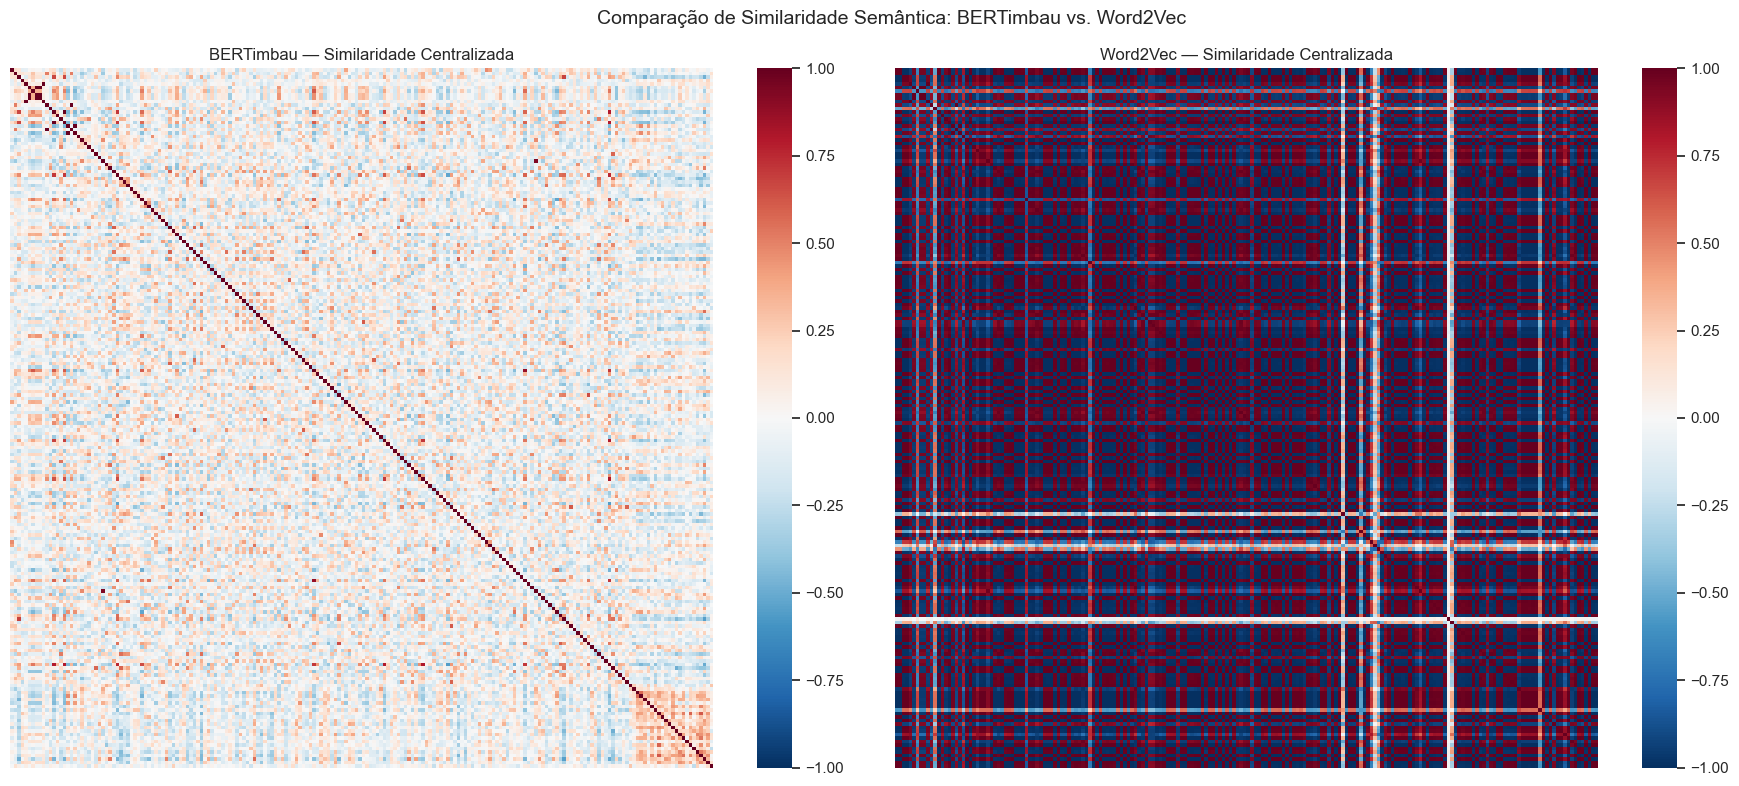

In [16]:
csv_p3 = os.path.join(DATA_DIR, '..', 'entregas', 'p3', 'entrega_3.csv')
if not os.path.exists(csv_p3):
    csv_p3 = os.path.join(DATA_DIR, 'entrega_3.csv')  # fallback

if os.path.exists(csv_p3):
    df_p3 = pd.read_csv(csv_p3)
    df_p3['vetor_w2v_parsed'] = df_p3['vetor_medio_word2vec'].apply(parse_vetor)
    valid_w2v = df_p3['vetor_w2v_parsed'].notna() & valid_mask  # alinhar com máscara BERT
    vetores_w2v = np.stack(df_p3.loc[valid_w2v, 'vetor_w2v_parsed'].values)
    vetores_bert_amostra = vetores[valid_w2v[valid_mask]]

    np.random.seed(seed)
    n_comp = min(200, len(vetores_bert_amostra))
    idx_comp = np.sort(np.random.choice(len(vetores_bert_amostra), size=n_comp, replace=False))

    bert_sample = vetores_bert_amostra[idx_comp]
    w2v_sample = vetores_w2v[idx_comp]

    bert_sample_cent = bert_sample - bert_sample.mean(axis=0)
    w2v_sample_cent = w2v_sample - w2v_sample.mean(axis=0)

    sim_bert = cosine_similarity(bert_sample_cent)
    sim_w2v = cosine_similarity(w2v_sample_cent)

    bert_upper = sim_bert[np.triu_indices_from(sim_bert, k=1)]
    w2v_upper = sim_w2v[np.triu_indices_from(sim_w2v, k=1)]

    print(f'Comparação em {n_comp} tweets:\n')
    print(f'BERTimbau (centralizado): média={bert_upper.mean():.4f}, std={bert_upper.std():.4f}')
    print(f'Word2Vec  (centralizado): média={w2v_upper.mean():.4f}, std={w2v_upper.std():.4f}')
    print(f'Correlação entre matrizes: {np.corrcoef(sim_bert.flatten(), sim_w2v.flatten())[0,1]:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.heatmap(sim_bert, annot=False, cmap='RdBu_r', center=0,
                xticklabels=False, yticklabels=False, ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title('BERTimbau — Similaridade Centralizada', fontsize=12)
    sns.heatmap(sim_w2v, annot=False, cmap='RdBu_r', center=0,
                xticklabels=False, yticklabels=False, ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title('Word2Vec — Similaridade Centralizada', fontsize=12)
    plt.suptitle('Comparação de Similaridade Semântica: BERTimbau vs. Word2Vec', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('arquivo entrega_3.csv não encontrado para comparação.')

conclusão